# Estudo de caso: Cyclistic

**Tarefa de negócio:** entender como membros anuais e passageiros casuais usam as bicicletas da Cyclistic de forma diferente, com o objetivo de embasar uma estratégia de marketing para converter passageiros casuais em membros anuais.

**Fonte de dados:** histórico de viagens da Divvy (Chicago), últimos 12 meses (agosto/2025 a julho/2026), disponibilizado publicamente pela Motivate International Inc.


# Import de Dependencias

## Preparar e processar

Antes da análise, os dados passaram pelas seguintes etapas de limpeza, aplicadas mês a mês:

- **Duração da viagem**: calculada como `ended_at - started_at`. Viagens com menos de 1 minuto (provável erro de destravamento) ou mais de 24 horas (provável bike não devolvida) foram removidas.
- **Coordenadas inválidas ("Null Island")**: linhas com latitude e longitude iguais a (0, 0) — indicativo de falha de GPS/registro — foram descartadas.
- **Nome de estação ausente**: quando `start_station_name`/`end_station_name` estava vazio mas a coordenada estava presente, o nome foi recuperado a partir de outra linha do mesmo mês com a mesma coordenada e nome preenchido.
- **Distância**: calculada via fórmula de Haversine a partir das coordenadas de início e fim de cada viagem (distância em linha reta, não a rota real pedalada).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
def haversine(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0  
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance_km = R * c
    return distance_km

In [ ]:
pasta = Path("data/")
file_names = [f.name for f in pasta.iterdir() if f.is_file()]


In [4]:
rows = []

casual_start_totals = pd.Series(dtype=int)
member_start_totals = pd.Series(dtype=int)

member_weekend_start_totals = pd.Series(dtype=int)
casual_weekend_start_totals = pd.Series(dtype=int)

for file_name in file_names:
    print(f"Processing file: {file_name}")

    df = pd.read_csv(f"data/tcc/{file_name}")

    ref_start = df.dropna(subset=["start_station_name"]).drop_duplicates(
        subset=["start_lat", "start_lng"]
    ).set_index(["start_lat", "start_lng"])["start_station_name"].to_dict()
    ref_end = df.dropna(subset=["end_station_name"]).drop_duplicates(
        subset=["end_lat", "end_lng"]
    ).set_index(["end_lat", "end_lng"])["end_station_name"].to_dict()

    df["start_station_name"] = df["start_station_name"].fillna(
        pd.Series(list(zip(df["start_lat"], df["start_lng"])), index=df.index).map(ref_start)
    )
    df["end_station_name"] = df["end_station_name"].fillna(
        pd.Series(list(zip(df["end_lat"], df["end_lng"])), index=df.index).map(ref_end)
    )
    df = df[~(((df["start_lat"] == 0) & (df["start_lng"] == 0)) |
              ((df["end_lat"] == 0) & (df["end_lng"] == 0)))]

    df["started_at"] = pd.to_datetime(df["started_at"])
    df["ended_at"] = pd.to_datetime(df["ended_at"])
    df["time_diff"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60
    df = df[(df["time_diff"] >= 1.0) & (df["time_diff"] <= 1440.0)]
    df = df[df["end_lat"].notna() & df["end_lng"].notna()]
    df["distance_km"] = haversine(df["start_lat"], df["start_lng"], df["end_lat"], df["end_lng"])
    df["day_of_week"] = df["started_at"].dt.strftime("%u")

    casual = df[df["member_casual"] == "casual"]
    member = df[df["member_casual"] == "member"]

    casual_preferred_day = casual["day_of_week"].mode()[0]
    member_preferred_day = member["day_of_week"].mode()[0]

    casual_day = casual[casual["day_of_week"] == casual_preferred_day]
    member_day = member[member["day_of_week"] == member_preferred_day]

    casual_classic = casual[casual["rideable_type"] == "classic_bike"]
    casual_electric = casual[casual["rideable_type"] == "electric_bike"]
    member_classic = member[member["rideable_type"] == "classic_bike"]
    member_electric = member[member["rideable_type"] == "electric_bike"]

    casual_classic_day = casual_day[casual_day["rideable_type"] == "classic_bike"]
    casual_electric_day = casual_day[casual_day["rideable_type"] == "electric_bike"]
    member_classic_day = member_day[member_day["rideable_type"] == "classic_bike"]
    member_electric_day = member_day[member_day["rideable_type"] == "electric_bike"]
    
    casual_start_totals = casual_start_totals.add(
    casual["start_station_name"].value_counts(), fill_value=0
)
    member_start_totals = member_start_totals.add(
       member["start_station_name"].value_counts(), fill_value=0
)
    
    member_weekend = member[member["day_of_week"].isin(["6", "7"])]
    casual_weekend = casual[casual["day_of_week"].isin(["6", "7"])]

    member_weekend_start_totals = member_weekend_start_totals.add(
    member_weekend["start_station_name"].value_counts(), fill_value=0
)
    casual_weekend_start_totals = casual_weekend_start_totals.add(
    casual_weekend["start_station_name"].value_counts(), fill_value=0
)

    rows.append({
        "file_name": file_name[:-4],

        # CASUAL - geral
        "casual_preferred_day": casual_preferred_day,
        "casual_avr_duration": casual["time_diff"].mean().round(2),
        "avr_casual_distance": casual["distance_km"].mean().round(2),
        "casual_preferred_start_station": casual["start_station_name"].mode()[0],
        "casual_preferred_end_station": casual["end_station_name"].mode()[0],
        "casual_preferred_start_station_in_preferred_day": casual_day["start_station_name"].mode()[0],
        "casual_preferred_end_station_in_preferred_day": casual_day["end_station_name"].mode()[0],

        # CASUAL - classic bike
        "casual_classic_count": len(casual_classic),
        "avr_casual_time_classic": casual_classic["time_diff"].mean().round(2),
        "avr_casual_distance_classic": casual_classic["distance_km"].mean().round(2),
        "casual_classic_in_preferred_day": len(casual_classic_day),
        "casual_classic_time_in_preferred_day": casual_classic_day["time_diff"].mean().round(2),
        "casual_classic_distance_in_preferred_day": casual_classic_day["distance_km"].mean().round(2),

        # CASUAL - electric bike
        "casual_electric_count": len(casual_electric),
        "avr_casual_time_electric": casual_electric["time_diff"].mean().round(2),
        "avr_casual_distance_electric": casual_electric["distance_km"].mean().round(2),
        "casual_electric_in_preferred_day_count": len(casual_electric_day),
        "casual_electric_time_in_preferred_day": casual_electric_day["time_diff"].mean().round(2),
        "casual_electric_distance_in_preferred_day": casual_electric_day["distance_km"].mean().round(2),

        # MEMBER - geral
        "member_preferred_day": member_preferred_day,
        "member_avr_duration": member["time_diff"].mean().round(2),
        "avr_member_distance": member["distance_km"].mean().round(2),
        "member_preferred_start_station": member["start_station_name"].mode()[0],
        "member_preferred_end_station": member["end_station_name"].mode()[0],
        "member_preferred_start_station_in_preferred_day": member_day["start_station_name"].mode()[0],
        "member_preferred_end_station_in_preferred_day": member_day["end_station_name"].mode()[0],

        # MEMBER - classic bike
        "member_classic_count": len(member_classic),
        "avr_member_time_classic": member_classic["time_diff"].mean().round(2),
        "avr_member_distance_classic": member_classic["distance_km"].mean().round(2),
        "member_classic_in_preferred_day": len(member_classic_day),
        "member_classic_time_in_preferred_day": member_classic_day["time_diff"].mean().round(2),
        "member_classic_distance_in_preferred_day": member_classic_day["distance_km"].mean().round(2),

        # MEMBER - electric bike
        "member_electric_count": len(member_electric),
        "avr_member_time_electric": member_electric["time_diff"].mean().round(2),
        "avr_member_distance_electric": member_electric["distance_km"].mean().round(2),
        "member_electric_in_preferred_day_count": len(member_electric_day),
        "member_electric_time_in_preferred_day": member_electric_day["time_diff"].mean().round(2),
        "member_electric_distance_in_preferred_day": member_electric_day["distance_km"].mean().round(2),
        
        #DAYS
        "casual_mon": (casual["day_of_week"] == "1").sum(),
        "casual_tue": (casual["day_of_week"] == "2").sum(),
        "casual_wed": (casual["day_of_week"] == "3").sum(),
        "casual_thu": (casual["day_of_week"] == "4").sum(),
        "casual_fri": (casual["day_of_week"] == "5").sum(),
        "casual_sat": (casual["day_of_week"] == "6").sum(),
        "casual_sun": (casual["day_of_week"] == "7").sum(),

        "member_mon": (member["day_of_week"] == "1").sum(),
        "member_tue": (member["day_of_week"] == "2").sum(),
        "member_wed": (member["day_of_week"] == "3").sum(),
        "member_thu": (member["day_of_week"] == "4").sum(),
        "member_fri": (member["day_of_week"] == "5").sum(),
        "member_sat": (member["day_of_week"] == "6").sum(),
        "member_sun": (member["day_of_week"] == "7").sum(),
      })

casual_top_stations = casual_start_totals.sort_values(ascending=False).head(10)
member_top_stations = member_start_totals.sort_values(ascending=False).head(10)

member_weekend_top = member_weekend_start_totals.sort_values(ascending=False).head(10)
casual_weekend_top = casual_weekend_start_totals.sort_values(ascending=False).head(10)
df = pd.DataFrame(rows)
df.head(len(df))

Processing file: 2025-08.csv
Processing file: 2025-09.csv
Processing file: 2025-10.csv
Processing file: 2025-11.csv
Processing file: 2025-12.csv
Processing file: 2026-01.csv
Processing file: 2026-02.csv
Processing file: 2026-03.csv
Processing file: 2026-04.csv
Processing file: 2026-05.csv
Processing file: 2026-06.csv
Processing file: 2026-07.csv


,file_name,casual_preferred_day,casual_avr_duration,avr_casual_distance,casual_preferred_start_station,casual_preferred_end_station,casual_preferred_start_station_in_preferred_day,casual_preferred_end_station_in_preferred_day,casual_classic_count,avr_casual_time_classic,...,casual_fri,casual_sat,casual_sun,member_mon,member_tue,member_wed,member_thu,member_fri,member_sat,member_sun
0,2025-08,6,21.68,2.36,Navy Pier,Navy Pier,Navy Pier,Navy Pier,117460,30.53,...,55228,77193,67387,52690,57982,66202,64946,74891,66237,60176
1,2025-09,6,19.56,2.33,Navy Pier,Navy Pier,Navy Pier,Navy Pier,80754,28.91,...,36380,46148,40785,70491,81563,64246,66406,60725,49998,47528
2,2025-10,6,18.10,2.18,Navy Pier,Navy Pier,Navy Pier,Navy Pier,66153,28.04,...,37039,42413,36532,51717,52862,73336,77638,68143,48904,41462
3,2025-11,6,15.16,1.95,Navy Pier,Navy Pier,Navy Pier,Navy Pier,27052,24.21,...,15284,22904,14785,34410,38057,40803,38465,37467,35510,27252
4,2025-12,2,12.82,1.67,Navy Pier,Navy Pier,Navy Pier,Navy Pier,6950,21.65,...,4069,4731,2182,17172,21985,20477,15738,15153,11958,6888
5,2026-01,2,13.07,1.64,Shedd Aquarium,Canal St & Madison St,Canal St & Madison St,Canal St & Madison St,5821,25.36,...,3697,3267,2822,15304,21634,19097,18656,15617,10920,8626
6,2026-02,5,14.09,1.84,Navy Pier,Navy Pier,Navy Pier,Navy Pier,11529,22.58,...,7551,5683,5195,21576,26378,28827,26796,25095,15706,12846
7,2026-03,6,16.88,2.00,Navy Pier,Navy Pier,Navy Pier,Navy Pier,23653,26.68,...,10494,19744,14219,41256,36763,29708,32184,28746,29322,25678
8,2026-04,4,16.67,2.10,Navy Pier,Navy Pier,Navy Pier,Navy Pier,33712,26.49,...,20412,19227,18690,39621,49681,57685,58461,42732,31007,29265
9,2026-05,6,19.65,2.26,Navy Pier,Navy Pier,Navy Pier,Navy Pier,65888,30.82,...,35402,55860,43856,50858,55788,59389,57252,64670,60675,50870


## Visualizar

Os gráficos a seguir traduzem os achados em recursos visuais para apoiar a apresentação à equipe executiva:

1. **Volume de viagens por mês** — evidencia a sazonalidade e a diferença de escala entre casual e member.
2. **Uso de bike elétrica vs. clássica por mês** — mostra a preferência consistente por elétrica em ambos os grupos, mês a mês.
3. **Total de viagens por dia da semana** — evidencia a concentração de member em dias úteis e de casual em fins de semana.
4. **Top 10 estações (geral)** — separa os pontos mais usados por cada grupo, revelando o padrão turístico (casual) vs. comercial (member).
5. **Top 10 estações no fim de semana** — mostra a mudança de comportamento do member aos sábados/domingos, aproximando-se do padrão casual.

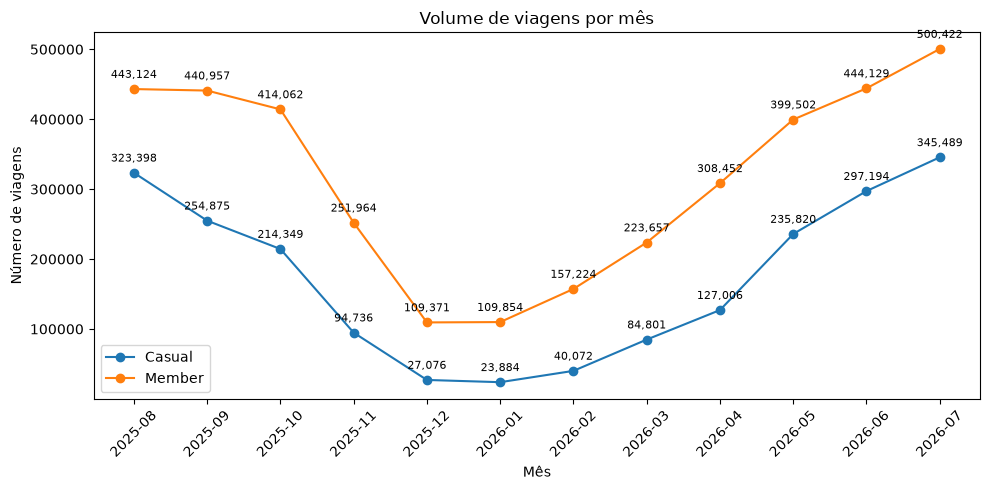

In [5]:
casual_total = df["casual_classic_count"] + df["casual_electric_count"]
member_total = df["member_classic_count"] + df["member_electric_count"]

plt.figure(figsize=(10, 5))
plt.plot(df["file_name"], casual_total, marker="o", label="Casual")
plt.plot(df["file_name"], member_total, marker="o", label="Member")

for x, y in zip(df["file_name"], casual_total):
    plt.annotate(f"{y:,}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

for x, y in zip(df["file_name"], member_total):
    plt.annotate(f"{y:,}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.title("Volume de viagens por mês")
plt.xlabel("Mês")
plt.ylabel("Número de viagens")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

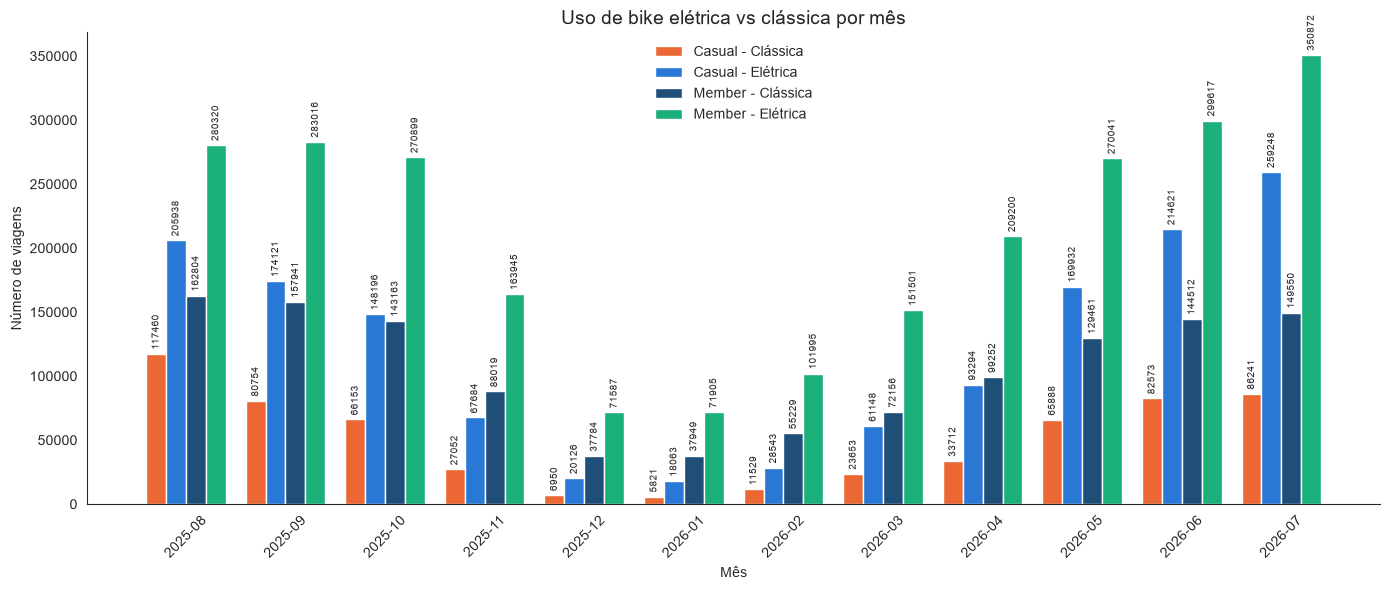

In [6]:

sns.set_style("white")
plt.rcParams["font.family"] = "sans-serif"

COLOR_CASUAL_CLASSIC = "#eb6834"  
COLOR_CASUAL_ELECTRIC = "#2a78d6" 
COLOR_MEMBER_CLASSIC = "#1F4E79"  
COLOR_MEMBER_ELECTRIC = "#1baf7a"  

x = np.arange(len(df["file_name"]))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

b1 = ax.bar(x - 1.5*width, df["casual_classic_count"], width, label="Casual - Clássica", color=COLOR_CASUAL_CLASSIC)
b2 = ax.bar(x - 0.5*width, df["casual_electric_count"], width, label="Casual - Elétrica", color=COLOR_CASUAL_ELECTRIC)
b3 = ax.bar(x + 0.5*width, df["member_classic_count"], width, label="Member - Clássica", color=COLOR_MEMBER_CLASSIC)
b4 = ax.bar(x + 1.5*width, df["member_electric_count"], width, label="Member - Elétrica", color=COLOR_MEMBER_ELECTRIC)

for bars in [b1, b2, b3, b4]:
    ax.bar_label(bars, fmt="%.0f", fontsize=7, rotation=90, padding=3)

ax.set_title("Uso de bike elétrica vs clássica por mês", fontsize=14)
ax.set_xlabel("Mês")
ax.set_ylabel("Número de viagens")
ax.set_xticks(x)
ax.set_xticklabels(df["file_name"], rotation=45)
ax.legend(frameon=False)
sns.despine()

plt.tight_layout()
plt.show()

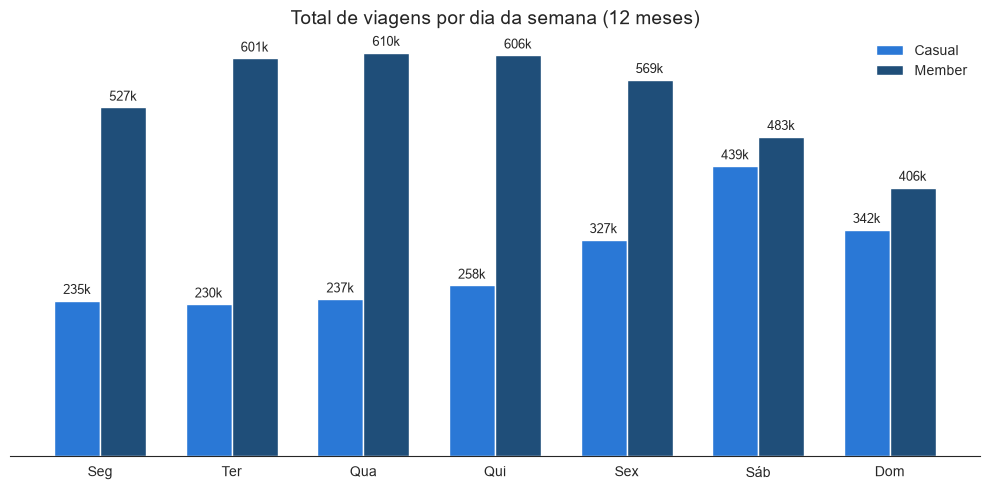

In [7]:
sns.set_style("white")
plt.rcParams["font.family"] = "sans-serif"

days = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]
day_labels = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

casual_totals = [df[f"casual_{d}"].sum() for d in days]
member_totals = [df[f"member_{d}"].sum() for d in days]

x = np.arange(len(days))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

b1 = ax.bar(x - width/2, casual_totals, width, label="Casual", color="#2a78d6")
b2 = ax.bar(x + width/2, member_totals, width, label="Member", color="#1F4E79")

for bars in [b1, b2]:
    ax.bar_label(bars, labels=[f"{v/1000:.0f}k" for v in bars.datavalues], fontsize=9, padding=3)

ax.set_title("Total de viagens por dia da semana (12 meses)", fontsize=14)
ax.set_ylabel("Número de viagens")
ax.set_xticks(x)
ax.set_xticklabels(day_labels)
ax.yaxis.set_visible(False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

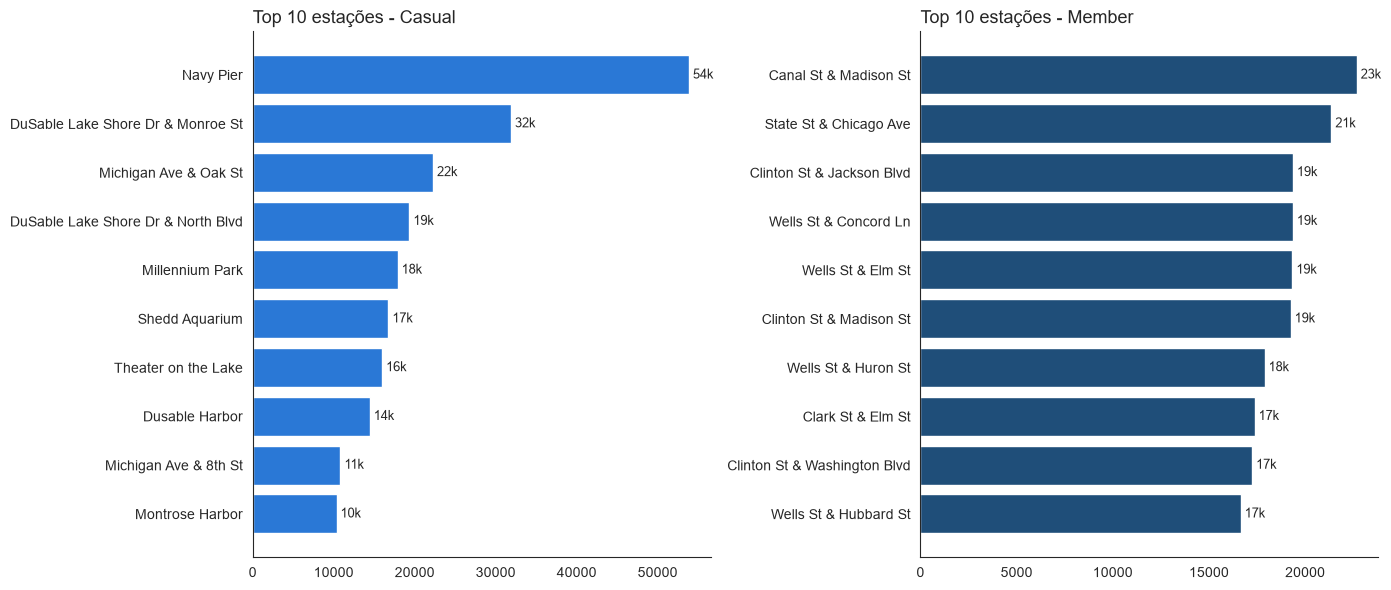

In [8]:

sns.set_style("white")
plt.rcParams["font.family"] = "sans-serif"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(casual_top_stations.index[::-1], casual_top_stations.values[::-1], color="#2a78d6")
axes[0].set_title("Top 10 estações - Casual", fontsize=13, loc="left")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].barh(member_top_stations.index[::-1], member_top_stations.values[::-1], color="#1F4E79")
axes[1].set_title("Top 10 estações - Member", fontsize=13, loc="left")
axes[1].spines[["top", "right"]].set_visible(False)

for ax in axes:
    for i, v in enumerate(ax.containers[0].datavalues):
        ax.text(v, i, f" {v/1000:.0f}k", va="center", fontsize=9)

plt.tight_layout()
plt.show()

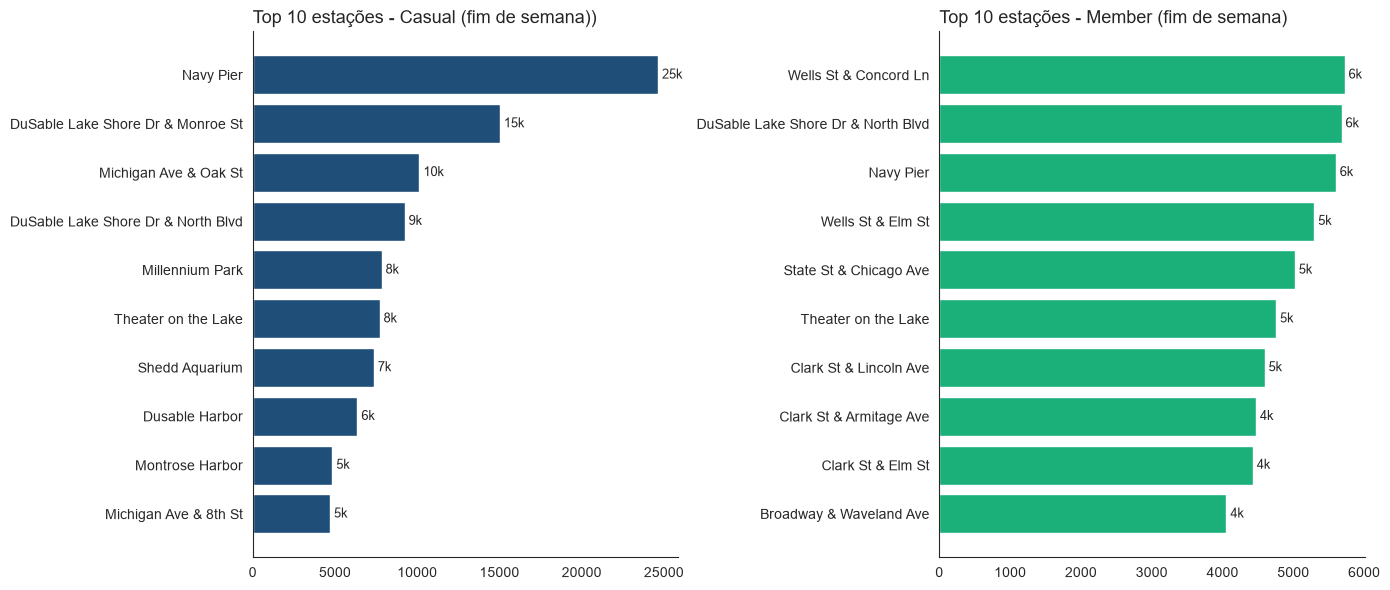

In [9]:
sns.set_style("white")
plt.rcParams["font.family"] = "sans-serif"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(casual_weekend_top.index[::-1], casual_weekend_top.values[::-1], color="#1F4E79")
axes[0].set_title("Top 10 estações - Casual (fim de semana)", fontsize=13, loc="left")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].barh(member_weekend_top.index[::-1], member_weekend_top.values[::-1], color="#1baf7a")
axes[1].set_title("Top 10 estações - Member (fim de semana)", fontsize=13, loc="left")
axes[1].spines[["top", "right"]].set_visible(False)

for ax in axes:
    for i, v in enumerate(ax.containers[0].datavalues):
        ax.text(v, i, f" {v/1000:.0f}k", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Resumo da análise
A análise dos últimos 12 meses de trajetos (agosto/2025 a julho/2026) revela um padrão de uso claramente distinto entre membros anuais e passageiros casuais. Membros concentram o uso em dias úteis, com preferência recorrente por terça a sexta-feira, e partem majoritariamente de estações situadas no distrito comercial de Chicago (Loop) — um padrão consistente com deslocamento para o trabalho. Passageiros casuais, por outro lado, concentram o uso aos sábados e domingos, partindo predominantemente de pontos turísticos e recreativos, como Navy Pier, a orla do lago Michigan e parques centrais — um padrão consistente com uso recreativo/turístico.

Vale destacar que uma parcela relevante dos membros adota um comportamento semelhante ao dos casuais durante o fim de semana: das dez estações mais usadas por membros aos sábados e domingos, seis passam a ser pontos turísticos/recreativos que não aparecem no top geral de dia útil — incluindo três estações (Navy Pier, DuSable Lake Shore Dr & North Blvd, Theater on the Lake) que também estão entre as mais usadas por casuais no mesmo período. Isso indica que existe um perfil de uso "casual" latente mesmo dentro da base de membros, e reforça esses pontos geográficos como locais estratégicos de contato entre os dois públicos.

Ambos os grupos apresentam forte sazonalidade: o volume de viagens cai de forma acentuada no inverno (dezembro a fevereiro) e atinge seu pico entre junho e julho, sendo essa queda proporcionalmente mais acentuada entre os casuais. Em todos os meses analisados, ambos os grupos preferem bicicletas elétricas às clássicas — inclusive nos dias de maior movimento. Um ponto importante: viagens elétricas percorrem distâncias muito próximas às viagens em bicicleta clássica, porém em bem menos tempo, o que indica que a preferência por elétrica está ligada à velocidade e conveniência, não a passeios mais longos ou de finalidade diferente.

### Recomendações

1. **Segmentar a campanha por perfil de uso, não por preço.** Casuais já pagam premium por bicicleta elétrica na maior parte das viagens, o que indica disposição a gastar mais por conveniência — não sensibilidade a preço. Uma calculadora de economia (comparando gasto avulso recorrente vs. plano anual) tende a converter melhor do que descontos genéricos.

2. **Priorizar a campanha entre março e julho.** É quando o volume de uso casual mais que quadruplica em relação ao inverno, maximizando o número de usuários expostos e o momento em que mais sentem o custo de viagens avulsas repetidas.

3. **Concentrar ações físicas em pontos de sobreposição geográfica.** Navy Pier, a orla do lago (DuSable Lake Shore Dr) e Theater on the Lake são usados tanto por casuais quanto por uma parcela de membros nos fins de semana — são os locais de maior potencial de contato entre os dois públicos, ideais para banners, QR codes ou parcerias locais.
